### `This is Supervised Task (Regression) & Evaluation Metric RMSE`

### `Import Libraries`

In [26]:
## Import the libraries
## major
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import missingno


## sklearn -- preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PowerTransformer, OrdinalEncoder, PolynomialFeatures
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn_features.transformers import DataFrameSelector

## sklearn -- metrics
from sklearn.metrics import mean_squared_error

## sklearn -- models
from sklearn.linear_model import LinearRegression, SGDRegressor, Ridge, Lasso, ElasticNet

### `Reading the Dataset and Look at the big picture`

In [2]:
## Read the csv file 
df = pd.read_csv('bikes.csv').drop(columns=['casual', 'registered'], axis=1)
df

,datetime,season,holiday,workingday,weather,temp,humidity,windspeed,rented_bikes_count
0,2011-01-01 00:00:00,Spring,0.0,0.0,Clear,9.84,81.0,NaN,16
1,2011-01-01 01:00:00,Spring,0.0,0.0,NaN,9.02,80.0,0.0000,40
2,2011-01-01 02:00:00,Spring,0.0,0.0,Clear,9.02,NaN,0.0000,32
3,2011-01-01 03:00:00,Spring,0.0,0.0,Clear,9.84,75.0,0.0000,13
4,2011-01-01 04:00:00,NaN,0.0,0.0,Clear,NaN,75.0,NaN,1
...,...,...,...,...,...,...,...,...,...
10881,2012-12-19 19:00:00,Winter,0.0,1.0,Clear,15.58,50.0,26.0027,336
10882,2012-12-19 20:00:00,Winter,0.0,1.0,NaN,14.76,NaN,NaN,241
10883,2012-12-19 21:00:00,NaN,0.0,1.0,Clear,13.94,61.0,15.0013,168
10884,2012-12-19 22:00:00,Winter,NaN,1.0,Clear,13.94,NaN,6.0032,129


In [3]:
## check the info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   datetime            10886 non-null  object 
 1   season              10672 non-null  object 
 2   holiday             10030 non-null  float64
 3   workingday          9388 non-null   float64
 4   weather             8746 non-null   object 
 5   temp                8104 non-null   float64
 6   humidity            7462 non-null   float64
 7   windspeed           6820 non-null   float64
 8   rented_bikes_count  10886 non-null  int64  
dtypes: float64(5), int64(1), object(3)
memory usage: 765.5+ KB


### `EDA`

<Axes: xlabel='season'>

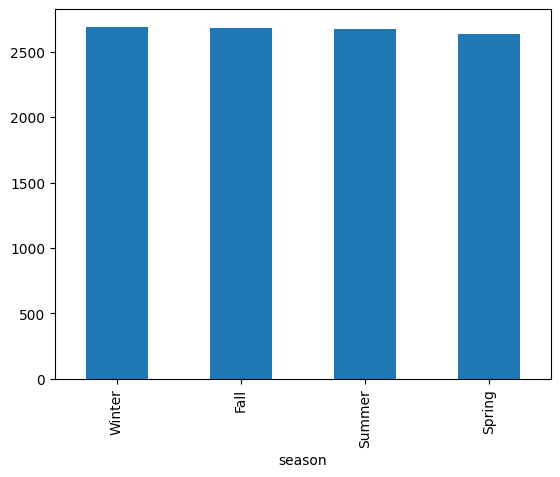

In [4]:
## Check the season
df['season'].value_counts().plot(kind='bar')

In [5]:
## Check  nans
df.isna().sum().sort_values(ascending=False) / df.shape[0]

windspeed             0.373507
humidity              0.314532
temp                  0.255558
weather               0.196583
workingday            0.137608
holiday               0.078633
season                0.019658
datetime              0.000000
rented_bikes_count    0.000000
dtype: float64

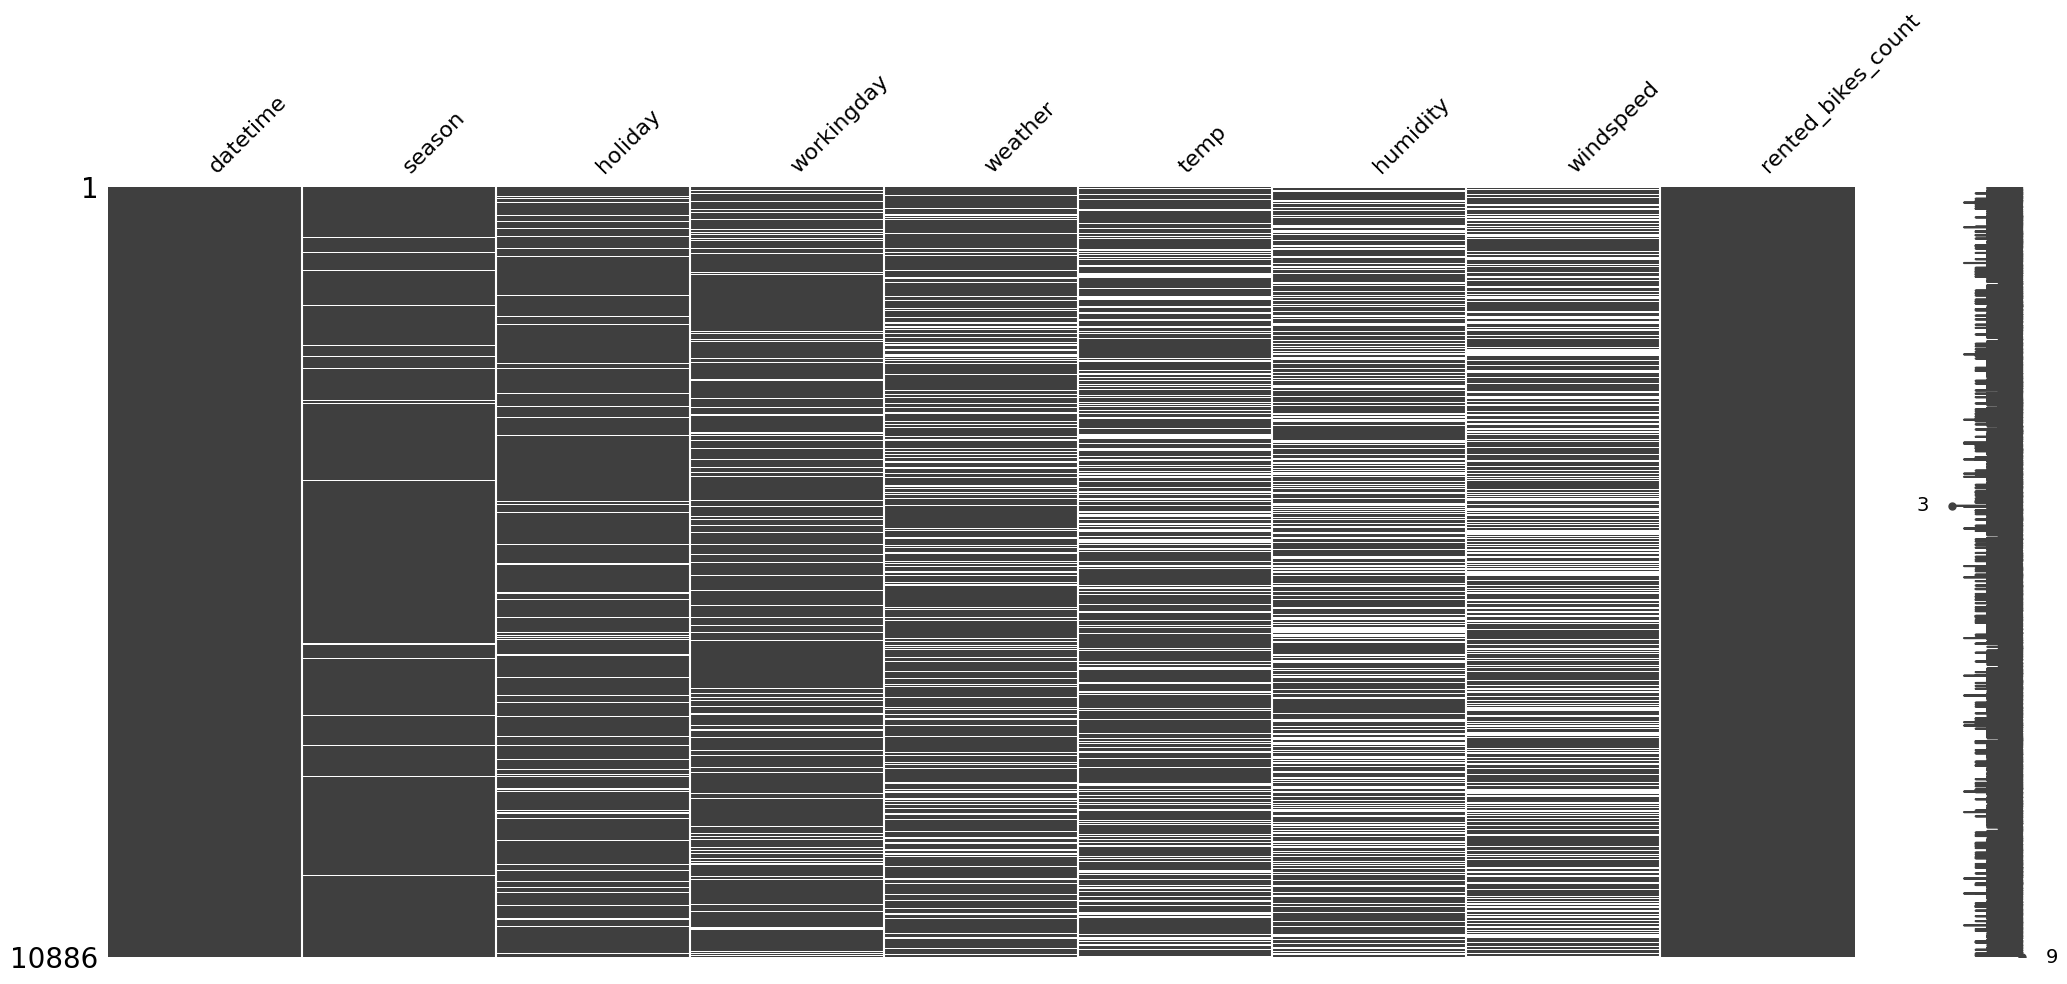

In [6]:
## missingno
missingno.matrix(df);

In [7]:
## Check holiday
df['holiday'].value_counts()

holiday
0.0    9738
1.0     292
Name: count, dtype: int64

In [8]:
df.shape[0] * 0.8

8708.800000000001

### `Split the Dataset`

In [9]:
## split to faetures and target
X = df.drop(columns=['rented_bikes_count'], axis=1)   ## faetures
y = df['rented_bikes_count']   ## traget

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, shuffle=True, random_state=102)

print('X_train.shape \t', X_train.shape)
print('y_train.shape \t', y_train.shape)
print('***'*20)
print('X_test.shape \t', X_test.shape)
print('y_test.shape \t', y_test.shape)

X_train.shape 	 (8164, 8)
y_train.shape 	 (8164,)
************************************************************
X_test.shape 	 (2722, 8)
y_test.shape 	 (2722,)


### `Data Preprocessing`

### `Feature Engineering`

In [10]:
## Modifying datetime
X_train['datetime'] = pd.to_datetime(X_train['datetime'], format='%Y-%m-%d %H:%M:%S')
X_test['datetime'] = pd.to_datetime(X_test['datetime'], format='%Y-%m-%d %H:%M:%S')

## Extract features
X_train['month_name'] = X_train['datetime'].dt.month_name()
X_test['month_name'] = X_test['datetime'].dt.month_name()

## Drop datetime -- now it is useless
X_train.drop(columns='datetime', axis=1, inplace=True)
X_test.drop(columns='datetime', axis=1, inplace=True)

### `Feature Tranfromation`

In [11]:
## Get the Numerical and Catgeorcial columns
num_cols = X_train.select_dtypes(include='number').columns.tolist()
categ_cols = X_train.select_dtypes(exclude='number').columns.tolist()

print('Numerical cols \t', num_cols)
print('Categorical cols \t', categ_cols)

Numerical cols 	 ['holiday', 'workingday', 'temp', 'humidity', 'windspeed']
Categorical cols 	 ['season', 'weather', 'month_name']


In [12]:
## Building pipeline

## Numerical pipeline
num_pipeline = Pipeline(steps=[
                        ('selector', DataFrameSelector(num_cols)),
                        ('imputer', SimpleImputer(strategy='median')),
                        ('transform', PowerTransformer(method='yeo-johnson', standardize=True))
                ])


## Catgeorical pipeline
categ_pipeline = Pipeline(steps=[
                ('selector', DataFrameSelector(categ_cols)),
                ('imputer', SimpleImputer(strategy='most_frequent')),
                ('encoder', OrdinalEncoder())
               ])


## Combine all
all_pipe = FeatureUnion(transformer_list=[
                ('num', num_pipeline),
                ('categ', categ_pipeline)
            ])

## fit and transform
X_train_final = all_pipe.fit_transform(X_train)
X_test_final = all_pipe.transform(X_test)

In [13]:
print('X_train_final.shape \t', X_train_final.shape)
print('y_train.shape \t', y_train.shape)
print('***'*10)
print('X_valid_final.shape \t', X_test_final.shape)
print('y_valid.shape \t', y_test.shape)

X_train_final.shape 	 (8164, 8)
y_train.shape 	 (8164,)
******************************
X_valid_final.shape 	 (2722, 8)
y_valid.shape 	 (2722,)


### `Building Models`

#### `1. Linear Regression`

In [ ]:
## intialize 
lin_reg = LinearRegression()
lin_reg.fit(X_train_final, y_train)   ## train


## Predict and Evaluate Model
y_pred_train_lin = lin_reg.predict(X_train_final)    ## you have the true value for train data (y_train)
y_pred_test_lin = lin_reg.predict(X_test_final)       ## you have the true value for train data (y_test)


## Evaluate Model USING RMSE
rmse_train_lin = np.sqrt(mean_squared_error(y_train, y_pred_train_lin))
rmse_test_lin = np.sqrt(mean_squared_error(y_test, y_pred_test_lin))

print(f'RMSE of Training Dataset using LinearRegression Model is: {rmse_train_lin:.3f}')
print(f'RMSE of Testing Dataset using LinearRegression Model is: {rmse_test_lin:.3f}')      ## No Overfitting

RMSE of Training Dataset using LinearRegression Model is: 161.223
RMSE of Testing Dataset using LinearRegression Model is: 165.389


### `2. Polynomail Features`

In [15]:
## Use degree=2
poly = PolynomialFeatures(degree=2, include_bias=False)
## fitting and transforming
X_train_final2 = poly.fit_transform(X_train_final)
X_test_final2 = poly.transform(X_test_final)


## Ready for Model ---> Uing LinearRegression
## intialize 
poly_reg = LinearRegression()
poly_reg.fit(X_train_final2, y_train)   ## train


## Predict and Evaluate Model
y_pred_train_poly = poly_reg.predict(X_train_final2)    ## you have the true value for train data (y_train)
y_pred_test_poly = poly_reg.predict(X_test_final2)       ## you have the true value for train data (y_test)


## Evaluate Model USING RMSE
rmse_train_poly = np.sqrt(mean_squared_error(y_train, y_pred_train_poly))
rmse_test_poly = np.sqrt(mean_squared_error(y_test, y_pred_test_poly))

print(f'RMSE of Training Dataset using LinearRegression with PolynomailFetaures is: {rmse_train_poly:.3f}')
print(f'RMSE of Testing Dataset using LinearRegression with PolynomailFetaures is: {rmse_test_poly:.3f}')     ## No Overfitting.

RMSE of Training Dataset using LinearRegression with PolynomailFetaures is: 157.609
RMSE of Testing Dataset using LinearRegression with PolynomailFetaures is: 162.163


### `SGD`

In [25]:
## Using SGD with Early Stopping
sgd_reg = SGDRegressor(penalty=None, learning_rate='constant', eta0=0.0001, early_stopping=True, 
                       n_iter_no_change=5, validation_fraction=0.1)
sgd_reg.fit(X_train_final, y_train)   ## training

## Predict and Evaluate Model
y_pred_train_sgd = sgd_reg.predict(X_train_final)    ## you have the true value for train data (y_train)
y_pred_test_sgd = sgd_reg.predict(X_test_final)       ## you have the true value for train data (y_test)


## Evaluate Model USING RMSE
rmse_train_sgd = np.sqrt(mean_squared_error(y_train, y_pred_train_sgd))
rmse_test_sgd = np.sqrt(mean_squared_error(y_test, y_pred_test_sgd))

print(f'RMSE of Training Dataset using SGDRegression is: {rmse_train_sgd:.3f}')
print(f'RMSE of Testing Dataset using SGDRegression is: {rmse_test_sgd:.3f}')     

RMSE of Training Dataset using SGDRegression is: 161.360
RMSE of Testing Dataset using SGDRegression is: 165.752


----

In [27]:
## Using Ridge for L2 Reg.
ridge = Ridge(alpha=0.5)
ridge.fit(X_train_final, y_train)

Ridge(alpha=0.5)

In [30]:
ridge.coef_, ridge.intercept_

(array([ -0.9129794 ,  -0.8768898 ,  63.53802899, -44.04277471,
          6.48163818,  18.80407198, -14.06141433,   3.72284744]),
 147.1744788323573)

In [40]:
## Lasso using L1 Reg.
lasso = Lasso(alpha=1)
lasso.fit(X_train_final, y_train)

Lasso(alpha=1)

In [41]:
lasso.coef_

array([ -0.        ,  -0.        ,  62.1301002 , -43.64424687,
         5.48755835,  17.55730967, -11.40487361,   3.67958463])

In [42]:
## ElasticNet
elastic = ElasticNet(alpha=1, l1_ratio=0.5)
elastic.fit(X_train_final, y_train)

ElasticNet(alpha=1)

In [44]:
elastic.coef_, elastic.intercept_

(array([ -0.42437369,  -0.        ,  39.64560282, -30.17468941,
          5.47837495,   7.71014593,  -7.98584355,   4.07609585]),
 159.50236549045053)

----

In [47]:
## Using SGD with any technique of Reg.
sgd = SGDRegressor(penalty='l2', alpha=0.001, learning_rate='constant', eta0=0.01)
sgd.fit(X_train_final, y_train.ravel())

SGDRegressor(alpha=0.001, learning_rate='constant')

In [48]:
sgd.coef_

array([ 11.73551153,  10.9982864 ,  62.92963765, -11.95031266,
         0.28212122,  51.86106758, -12.61990391,  43.49290817])

--------